# Chromatin MNase-seq normalization.

There is variation in the samples between the timepoints in each replicate. And also between the replicates

This notebook will compute the normalization for each replicate and each sample to ensure that the length distributions are equivalent for each sample.

First we will compute the counts per each length for each sample. Plot these. Compute how they need to be scaled. Then plot the result of applying the scaling factor.

For the deconvolution, we can use this scaling matrix to adjust the G matrix prior to deconvolution. 


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
rep1_subset_scaling_mat = pd.read_csv('output/mnase/rep1_len_scaling_3len_bins.csv')
rep2_subset_scaling_mat = pd.read_csv('output/mnase/rep2_len_scaling_3len_bins.csv')

rep1_subset_scaling_mat = rep1_subset_scaling_mat.rename(columns={"Unnamed: 0": "time"}).set_index('time')
rep2_subset_scaling_mat = rep2_subset_scaling_mat.rename(columns={"Unnamed: 0": "time"}).set_index('time')

In [10]:
rep1_subset_scaling_mat.head(1)

,"(0, 100)","(100, 145)","(145, 195)"
time,,,
0,0.468794,0.722742,0.702182


In [23]:
# Let's test this scaling by looking at a gene's deconvolution
# We will look at CLB2 and see how the scaling affects the read counts of the raw data

from src.config import load_yl_replicate1_rg1_alpha_vst_config, \
    load_yl_replicate2_rg1_alpha_vst_config
from cc_src.chromatin_model import ChromatinModel

config1 = load_yl_replicate1_rg1_alpha_vst_config()
config2 = load_yl_replicate2_rg1_alpha_vst_config()

gene_name = 'CLB2'
chrom1_model = ChromatinModel(config1)
chrom1_model.load_mnase_gene(gene_name, replicate=1)

chrom2_model = ChromatinModel(config2)
chrom2_model.load_mnase_gene(gene_name, replicate=2)

Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
Now we have a data structure that we can try to deconvolve of shape: (16, 27)
Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


In [24]:
# Applies the scaling normalization matrix and recreates the deconvolution histogram
# for deconvolution
chrom1_model.apply_normalization(rep1_subset_scaling_mat)
chrom2_model.apply_normalization(rep2_subset_scaling_mat)

Now we have a data structure that we can try to deconvolve of shape: (16, 27)
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


In [15]:
def plot_comparison_normalized(chrom1_model):

    def plot_hist(hist):
        plt.imshow(hist, origin='lower', vmax=150, cmap='magma_r', aspect='auto')
        plt.xticks([])
        plt.yticks([])

    n = len(chrom1_model.times)

    plt.figure(figsize=(2, 9))
    for tp_idx in range(n):

        # Here is the raw data for timepoint 1
        plt.subplot(n, 2, 1+tp_idx*2)
        plot_hist(chrom1_model.unnormalized_all_hists[tp_idx])

        # Now, plot the normalized bins
        plt.subplot(n, 2, 1+tp_idx*2+1)
        plot_hist(chrom1_model.normalized_tps_hists[tp_idx])


Text(0.5, 0.98, 'Replicate 1')

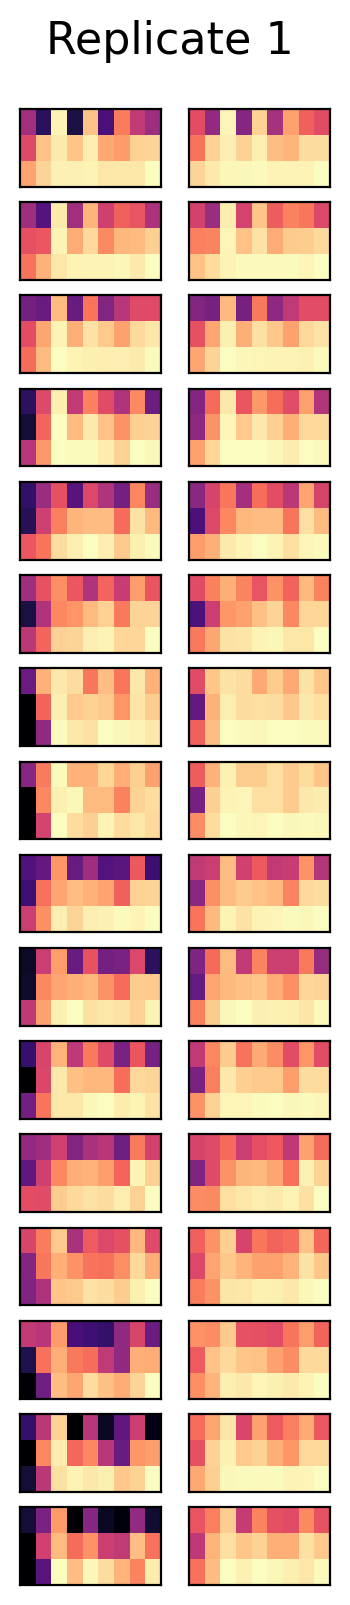

In [25]:
plot_comparison_normalized(chrom1_model)
plt.subplots_adjust(top=0.93)
plt.suptitle("Replicate 1", fontsize=16)

Text(0.5, 0.98, 'Replicate 2')

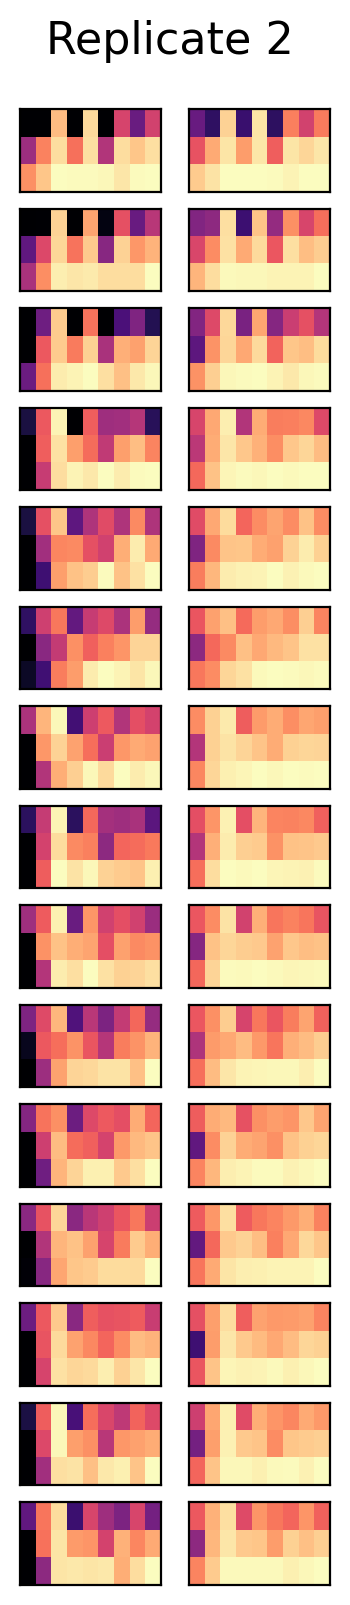

In [26]:
plot_comparison_normalized(chrom2_model)
plt.subplots_adjust(top=0.93)
plt.suptitle("Replicate 2", fontsize=16)

Text(0.5, 0.98, 'Mean counts for small, med, nuc fragments for CLB2')

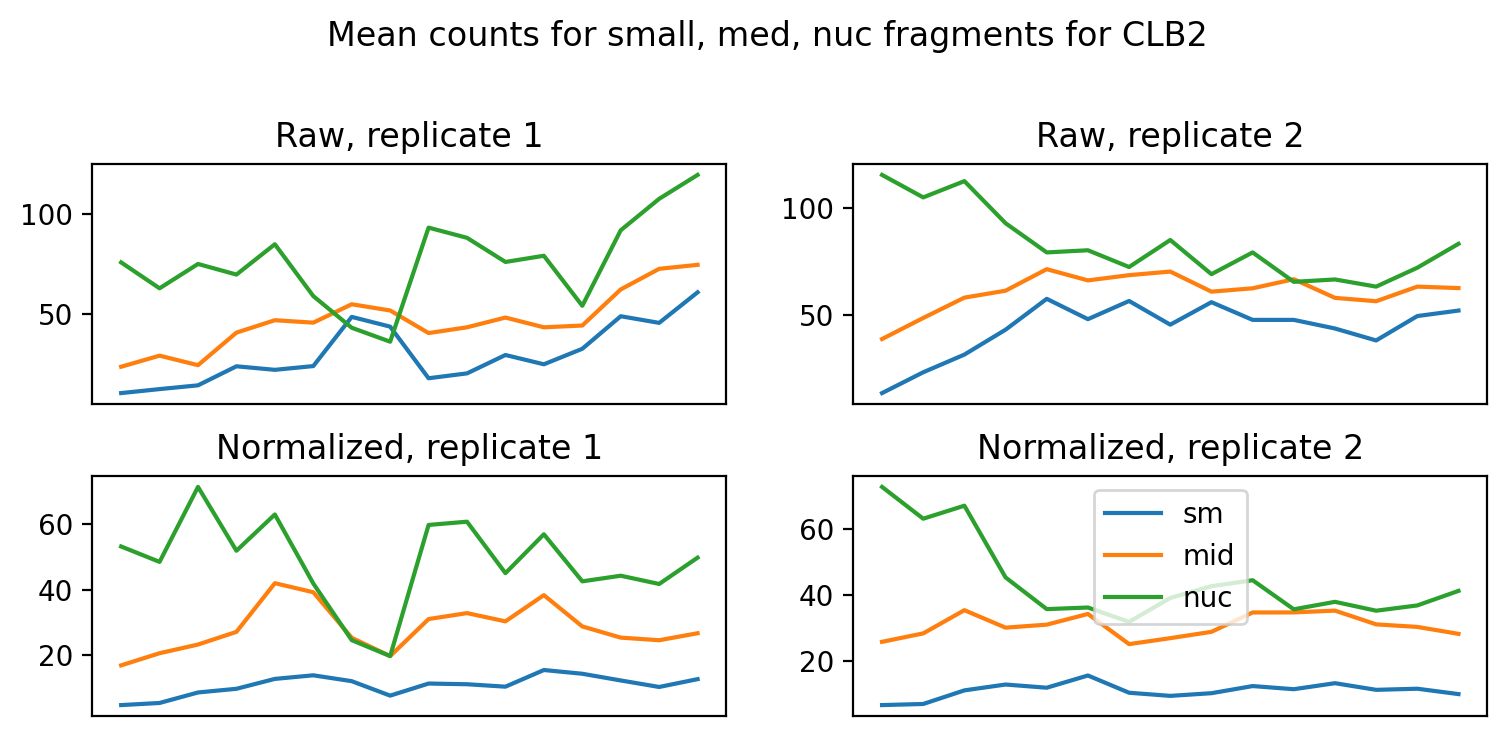

In [366]:
plt.figure(figsize=(9, 4))
plt.subplots_adjust(hspace=0.3, top=0.8)
plt.subplot(2, 2, 1)
plt.plot(chrom1_model.unnormalized_all_hists.mean(axis=2))
plt.xticks([])
plt.title("Raw, replicate 1")
plt.subplot(2, 2, 2)
plt.plot(chrom2_model.unnormalized_all_hists.mean(axis=2))
plt.xticks([])
plt.title("Raw, replicate 2")

plt.subplot(2, 2, 3)
plt.plot(chrom1_model.normalized_tps_hists.mean(axis=2))
plt.xticks([])
plt.title("Normalized, replicate 1")
plt.subplot(2, 2, 4)
plt.plot(chrom2_model.normalized_tps_hists.mean(axis=2), 
         label=['sm', 'mid', 'nuc'])
plt.xticks([])
plt.title("Normalized, replicate 2")
plt.legend()

plt.suptitle("Mean counts for small, med, nuc fragments for CLB2")

In [27]:
from src.model import Model

ge_model1 = Model(config1, gene_name)
ge_model1.deconvolve_find_optimal_gamma()

In [28]:
ge_model2 = Model(config2, gene_name)
ge_model2.deconvolve_find_optimal_gamma()

In [169]:
chrom1_model.deconvolve_find_optimal()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 0.8319
  ... Searching for an optimal gamma value in the boundaries: [0.0010, 0.1000]
  ...  search left, rn_goal = 0.9119, rate = 9.6
  ...   gm = 0.0505, rn = 0.9692, rate = 16.50, time = 00:00:43.12
  ...   gm = 0.0258, rn = 0.9199, rate = 10.58, time = 00:00:56.82
  ...   gm = 0.0134, rn = 0.8909, rate = 7.09, time = 00:01:10.13
  ...   gm = 0.0196, rn = 0.9066, rate = 8.98, time = 00:01:23.88
  ...   gm = 0.0227, rn = 0.9134, rate = 9.79, time = 00:01:37.96
  ...   gm = 0.0211, rn = 0.9101, rate = 9.39, time = 00:01:51.42
  ...  search right, rn_goal = 1.1647, rate = 40.0
  ... rn range: [0.9101, 1.0382]
  ... search gamma in [0.0211 0.1000] for elbow
  ...   gm = 0.0211, rn = 0.9101, rate = 9.39, time = 00:02:19.05
  ...   gm = 0.0290, rn = 0.9270, rate = 11.42, time = 00:02:32.81
  ...   gm = 0.0369, rn = 0.9437, rate = 13.44, time = 00:02:48.21
  ...   gm = 0.0448, rn = 

In [170]:
chrom2_model.deconvolve_find_optimal()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 0.3438
  ... Searching for an optimal gamma value in the boundaries: [0.0010, 0.1000]
  ...  search left, rn_goal = 0.3782, rate = 10.0
  ...   gm = 0.0505, rn = 0.4169, rate = 21.25, time = 00:00:44.52
  ...   gm = 0.0258, rn = 0.3950, rate = 14.88, time = 00:01:02.23
  ...   gm = 0.0134, rn = 0.3838, rate = 11.62, time = 00:01:17.55
  ...   gm = 0.0072, rn = 0.3753, rate = 9.16, time = 00:01:31.19
  ...   gm = 0.0103, rn = 0.3810, rate = 10.81, time = 00:01:46.47
  ...  search right, rn_goal = 0.6638, rate = 93.1
  ... rn range: [0.3782, 0.4597]
  ... search gamma in [0.0087 0.1000] for elbow
  ...   gm = 0.0087, rn = 0.3782, rate = 10.01, time = 00:02:28.48
  ...   gm = 0.0179, rn = 0.3882, rate = 12.92, time = 00:02:44.49
  ...   gm = 0.0270, rn = 0.3960, rate = 15.19, time = 00:02:59.73
  ...   gm = 0.0361, rn = 0.4049, rate = 17.76, time = 00:03:16.07
  ...   gm = 0.0452, 

In [173]:
# Precomputed gamma values, it takes about 10 minutes, so let's start with these values
# as we debug the fits
optimal_gamma1 = 0.07633
optimal_gamma2 = 0.05437

chrom1_model.gamma = optimal_gamma1
chrom2_model.gamma = optimal_gamma2

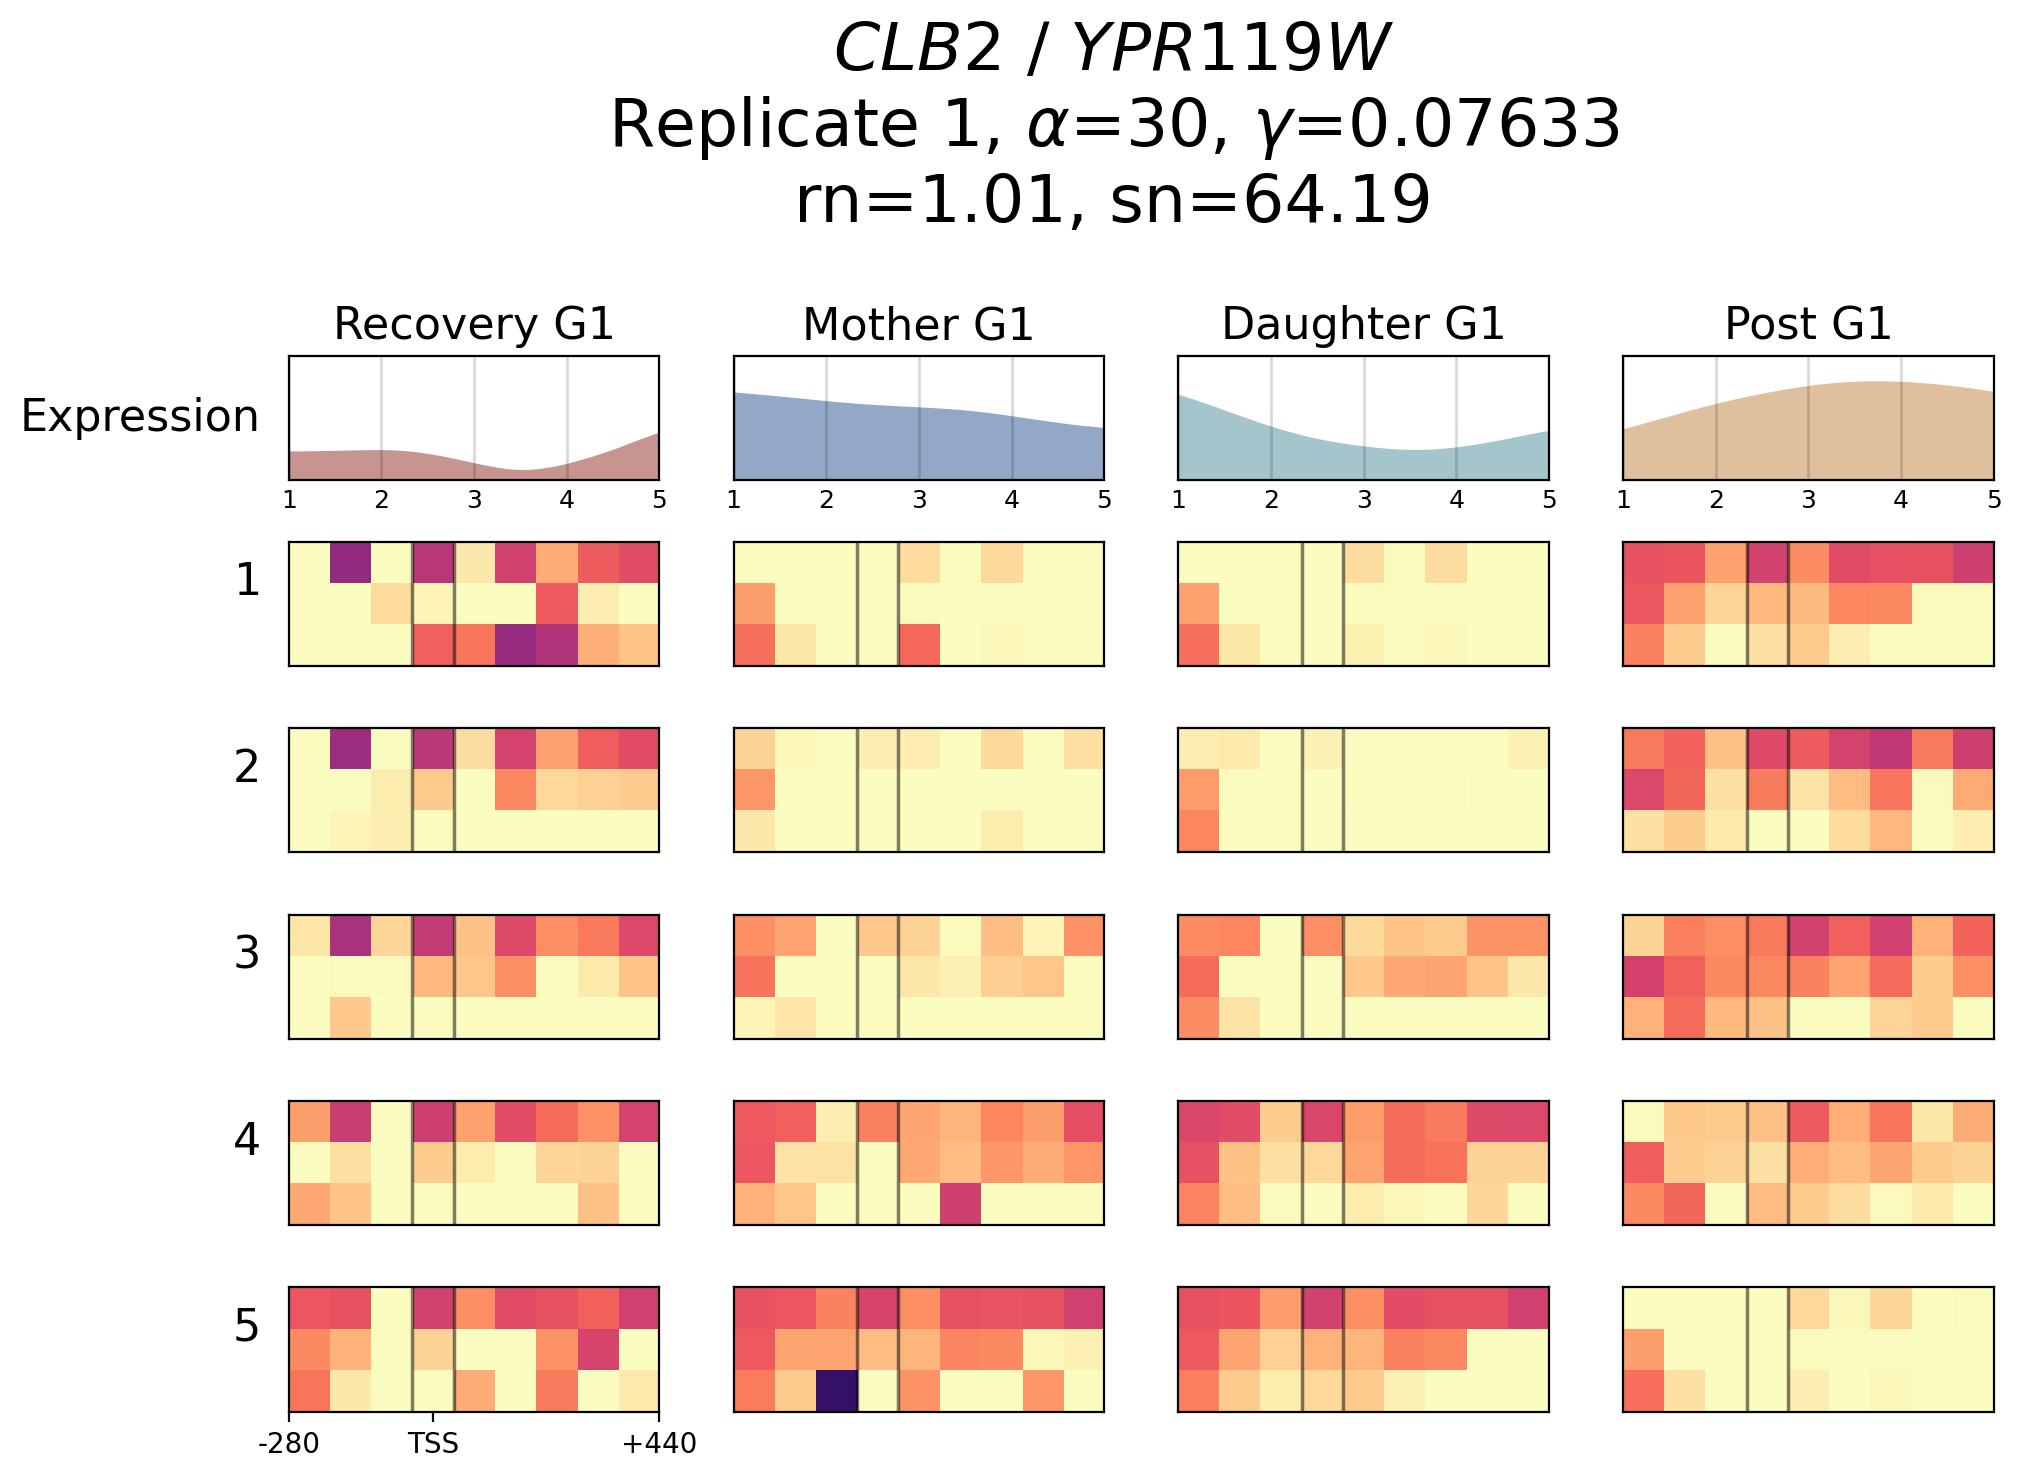

In [171]:
chrom1_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model1)

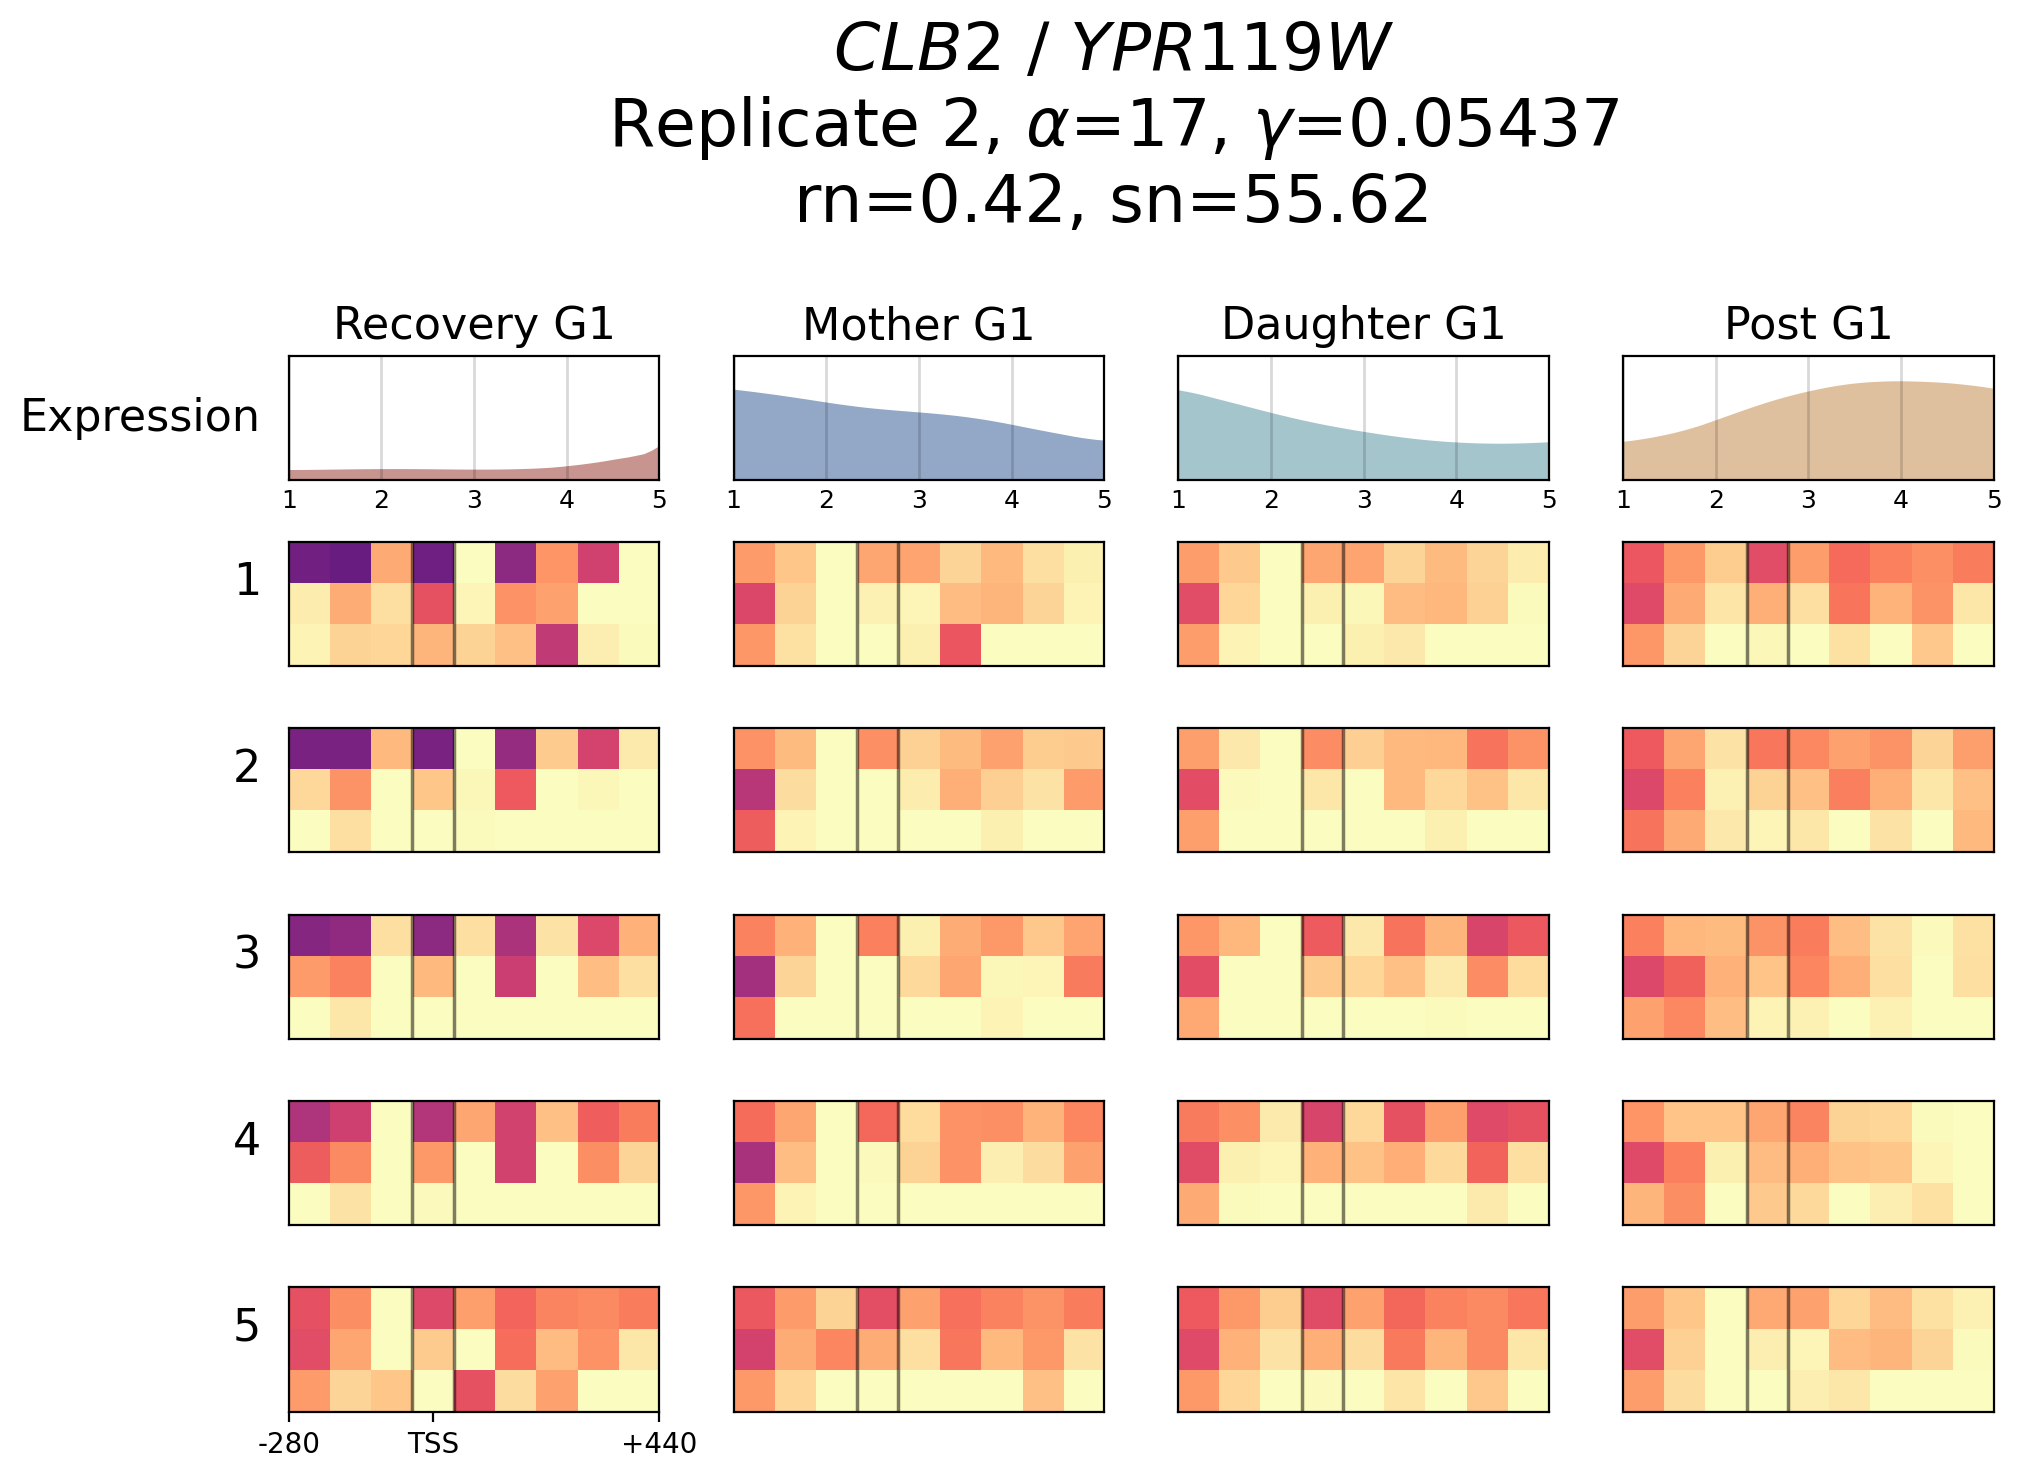

In [172]:
chrom2_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model2)